# Multipath Effects on the Switched UCA

This notebook investigates how a reflected signal path affects direction-of-arrival estimation using the proposed switched UCA.

The simulation follows the intended hardware processing chain:

$$
\text{Array geometry}
\rightarrow
\text{direct + reflected propagation}
\rightarrow
\text{switched measurements}
\rightarrow
\text{centre referencing}
\rightarrow
\text{Bartlett AoA estimation}.
$$

The purpose is to determine how multipath changes the recovered array measurement and biases the estimated transmitter direction.

In [2]:
using LinearAlgebra
using Plots
using Random
using Statistics

## 1. Array Geometry

The same six-element UCA geometry used in the previous simulations is retained.

The array operates at a nominal frequency of 433 MHz. The neighbouring outer-antenna spacing is chosen as

$$
d = 0.4\lambda
$$

where

$$
\lambda = \frac{c}{f}.
$$

For a UCA with $N$ outer antennas, the required radius is

$$
R = \frac{d}{2\sin(\pi/N)}.
$$

For $N=6$, this gives $R=d$.

In [3]:
# Basic constants
c = 3e8
f = 433e6
λ = c / f

# Six outer antennas
N = 6

# Fixed physical UCA geometry
d = 0.4 * λ
R = d / (2 * sin(π / N))

# Angular position of each outer antenna
phi = (0:N-1) .* (2 * π / N)

# Cartesian position of each outer antenna
x = R .* cos.(phi)
y = R .* sin.(phi)

println("Frequency = ", f / 1e6, " MHz")
println("Wavelength = ", round(λ, digits=3), " m")
println("Neighbour spacing = ", round(d, digits=3), " m")
println("Array radius = ", round(R, digits=3), " m")

Frequency = 433.0 MHz
Wavelength = 0.693 m
Neighbour spacing = 0.277 m
Array radius = 0.277 m


## 2. Multipath Environment

The UCA centre is placed at the origin. A transmitter is positioned 5 m away at a true azimuth of $30^\circ$.

A single reflector is represented by a point in the surrounding environment. This gives two propagation paths:

$$
L_{\text{direct}}
=
\text{TX} \rightarrow \text{array centre}
$$

and

$$
L_{\text{reflected}}
=
\text{TX} \rightarrow \text{reflector}
\rightarrow \text{array centre}.
$$

The additional distance travelled by the reflected signal is

$$
\Delta L
=
L_{\text{reflected}}-L_{\text{direct}}.
$$

This produces an additional propagation phase

$$
\delta
=
\frac{2\pi}{\lambda}\Delta L.
$$

The final reflector-to-array path also determines the direction from which the reflected wave appears to arrive at the UCA.

In [4]:
# True transmitter direction
phi_direct_deg = 30
phi_direct = deg2rad(phi_direct_deg)

# Distance from the UCA centre to the transmitter
TX_distance = 5.0

# Transmitter position
TX_x = TX_distance * cos(phi_direct)
TX_y = TX_distance * sin(phi_direct)

# Position of one reflecting object
reflector_x = 2.0
reflector_y = 4.0

# Horizontal-plane simulation
theta0 = deg2rad(90)

println(
    "Transmitter position = (",
    round(TX_x, digits=2), ", ",
    round(TX_y, digits=2), ") m"
)

println(
    "Reflector position = (",
    reflector_x, ", ",
    reflector_y, ") m"
)

Transmitter position = (4.33, 2.5) m
Reflector position = (2.0, 4.0) m


In [5]:
# Direct path from transmitter to array centre
L_direct = sqrt(TX_x^2 + TX_y^2)

# Transmitter to reflector
L_TX_reflector = sqrt(
    (TX_x - reflector_x)^2 +
    (TX_y - reflector_y)^2
)

# Reflector to array centre
L_reflector_array = sqrt(
    reflector_x^2 +
    reflector_y^2
)

# Total reflected path
L_reflected = L_TX_reflector + L_reflector_array

# Extra distance travelled by the reflected signal
ΔL = L_reflected - L_direct

# Direction from which the reflection arrives at the array
phi_reflected = atan(reflector_y, reflector_x)

# Extra propagation phase caused by the longer path
reflection_phase = (2 * π / λ) * ΔL

println("Direct path length = ", round(L_direct, digits=3), " m")
println("Reflected path length = ", round(L_reflected, digits=3), " m")
println("Excess path length = ", round(ΔL, digits=3), " m")

println(
    "Reflected arrival direction = ",
    round(rad2deg(phi_reflected), digits=2), "°"
)

Direct path length = 5.0 m
Reflected path length = 7.243 m
Excess path length = 2.243 m
Reflected arrival direction = 63.43°


## 3. Direct and Reflected Array Signals

The direct and reflected waves produce different phase patterns across the UCA because they arrive from different directions.

For outer antenna $i$, the direct-path geometric phase is

$$
\psi_{d,i}
=
\frac{2\pi R}{\lambda}
\cos(\phi_d-\phi_i),
$$

while the reflected-path phase is

$$
\psi_{r,i}
=
\frac{2\pi R}{\lambda}
\cos(\phi_r-\phi_i).
$$

The reflected signal is assigned a relative received amplitude $\rho$. This represents the combined effect of the longer propagation path and reflection loss.

The outer antenna therefore receives

$$
x_i^{(m)}
=
e^{j\alpha_m}
\left[
e^{j\psi_{d,i}}
+
\rho e^{j(\delta+\psi_{r,i})}
\right].
$$

In [6]:
# Direct-path phase pattern across the outer antennas
OD_direct = R .* cos.(phi_direct .- phi) .* sin(theta0)
phase_direct = (2 * π / λ) .* OD_direct

# Reflected-path phase pattern across the outer antennas
OD_reflected = R .* cos.(phi_reflected .- phi) .* sin(theta0)
phase_reflected = (2 * π / λ) .* OD_reflected

# Reflected signal amplitude relative to the direct signal
reflection_amplitude = 0.5

println("Reflection amplitude = ", reflection_amplitude)

Reflection amplitude = 0.5


## 4. Switched Centre-Reference Processing

The proposed hardware uses one continuously measured centre antenna and one switched outer-antenna channel.

The transmitter phase may change between switch positions. This common phase is represented by $\alpha_m$.

The centre antenna receives

$$
x_c^{(m)}
=
e^{j\alpha_m}
\left[
1+\rho e^{j\delta}
\right].
$$

For outer antenna $i$,

$$
x_i^{(m)}
=
e^{j\alpha_m}
\left[
e^{j\psi_{d,i}}
+
\rho e^{j(\delta+\psi_{r,i})}
\right].
$$

Centre referencing is performed using

$$
z_i
=
x_i^{(m)}
\left(x_c^{(m)}\right)^*.
$$

The common phase $\alpha_m$ is removed, while the direction-dependent multipath contribution remains.

In [7]:
# Example common signal phase at each switch position
common_phase_deg = [20, 50, 80, 110, 140, 170]
common_phase = deg2rad.(common_phase_deg)

# Centre-reference measurements
centre_signal = exp.(im .* common_phase) .* (
    1 .+
    reflection_amplitude .* exp(im * reflection_phase)
)

# Switched outer-antenna measurements
outer_signal = exp.(im .* common_phase) .* (
    exp.(im .* phase_direct) .+
    reflection_amplitude .* exp.(
        im .* (reflection_phase .+ phase_reflected)
    )
)

println("Centre and switched outer measurements generated.")

Centre and switched outer measurements generated.


In [8]:
# Remove the common signal phase using the centre antenna
recovered_multipath =
    outer_signal .* conj.(centre_signal)

# Direct-path measurement used later for comparison
recovered_direct =
    exp.(im .* phase_direct)

println("Centre-referenced array measurement recovered.")

Centre-referenced array measurement recovered.


## 5. Bartlett Direction Estimation

The recovered six-element measurement vector is processed using conventional Bartlett beamforming.

For each test azimuth $\phi$, a UCA steering vector $\mathbf{a}(\phi)$ is generated. The Bartlett response is calculated as

$$
P_B(\phi)
=
\left|
\mathbf{a}^{H}(\phi)\mathbf{z}
\right|.
$$

The estimated direction is the angle producing the largest response:

$$
\hat{\phi}
=
\underset{\phi}{\operatorname{arg\,max}}
\;P_B(\phi).
$$

In [9]:
# Angles used for the Bartlett search
phi_scan_deg = 0:0.1:359.9

# Store the direct and multipath responses
score_direct = zeros(length(phi_scan_deg))
score_multipath = zeros(length(phi_scan_deg))

for k in eachindex(phi_scan_deg)

    phi_test = deg2rad(phi_scan_deg[k])

    # Steering vector for this test direction
    OD_test =
        R .* cos.(phi_test .- phi) .* sin(theta0)

    phase_test =
        (2 * π / λ) .* OD_test

    steering =
        exp.(im .* phase_test)

    # Direct-path response
    score_direct[k] =
        abs(sum(conj.(steering) .* recovered_direct))

    # Multipath response
    score_multipath[k] =
        abs(sum(conj.(steering) .* recovered_multipath))
end

# Normalise both responses
score_direct ./= maximum(score_direct)
score_multipath ./= maximum(score_multipath)

# Estimated direction under multipath
phi_est =
    phi_scan_deg[argmax(score_multipath)]

# Circular bearing error
bearing_error =
    mod(phi_est - phi_direct_deg + 180, 360) - 180

println("True direction = ", phi_direct_deg, "°")
println(
    "Reflection arrival direction = ",
    round(rad2deg(phi_reflected), digits=2), "°"
)
println("Estimated direction = ", phi_est, "°")
println(
    "Bearing error = ",
    round(bearing_error, digits=2), "°"
)

True direction = 30°
Reflection arrival direction = 63.43°
Estimated direction = 34.4°
Bearing error = 4.4°


## 6. Results

The direct-path and multipath Bartlett responses are compared to show how the reflected signal changes the spatial response of the array.

The reflected path does not necessarily create a separate dominant peak. Instead, coherent addition of the direct and reflected signals can distort and shift the main Bartlett lobe, producing a biased direction estimate.

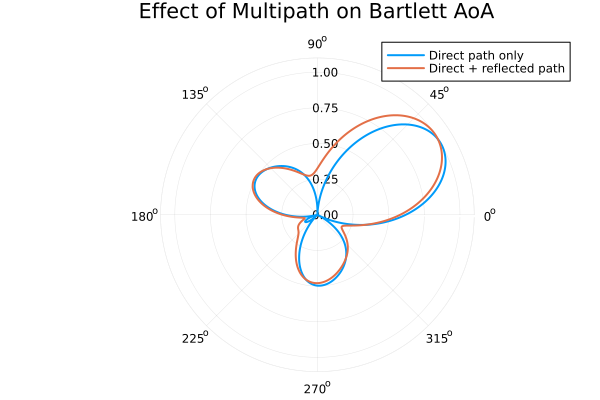

In [10]:
# Compare the ideal direct-path response with the multipath response

plot(
    deg2rad.(phi_scan_deg),
    score_direct,
    proj = :polar,
    linewidth = 2,
    label = "Direct path only",
    title = "Effect of Multipath on Bartlett AoA",
    rlims = (0, 1)
)

plot!(
    deg2rad.(phi_scan_deg),
    score_multipath,
    linewidth = 2,
    label = "Direct + reflected path"
)

## 7. Sensitivity to Reflection Strength

The physical transmitter and reflector positions are kept fixed while the reflected signal strength is varied.

This shows how the Bartlett bearing error changes as the reflected component becomes stronger relative to the direct signal.

In [11]:
# Reflection strengths to test
reflection_amplitude_test = 0.0:0.1:1.0

# Store the estimated bearing and error
estimated_angles = zeros(length(reflection_amplitude_test))
reflection_errors = zeros(length(reflection_amplitude_test))

for r in eachindex(reflection_amplitude_test)

    ρ = reflection_amplitude_test[r]

    # Centre measurement
    centre_test = exp.(im .* common_phase) .* (
        1 .+
        ρ .* exp(im * reflection_phase)
    )

    # Outer antenna measurements
    outer_test = exp.(im .* common_phase) .* (
        exp.(im .* phase_direct) .+
        ρ .* exp.(
            im .* (reflection_phase .+ phase_reflected)
        )
    )

    # Centre-reference the measurement
    recovered_test =
        outer_test .* conj.(centre_test)

    # Bartlett scan
    score_test = zeros(length(phi_scan_deg))

    for k in eachindex(phi_scan_deg)

        phi_test = deg2rad(phi_scan_deg[k])

        OD_test =
            R .* cos.(phi_test .- phi) .* sin(theta0)

        phase_test =
            (2 * π / λ) .* OD_test

        steering =
            exp.(im .* phase_test)

        score_test[k] =
            abs(sum(conj.(steering) .* recovered_test))
    end

    # Estimate the direction
    estimated_angles[r] =
        phi_scan_deg[argmax(score_test)]

    # Circular bearing error
    reflection_errors[r] =
        mod(
            estimated_angles[r] -
            phi_direct_deg +
            180,
            360
        ) - 180
end

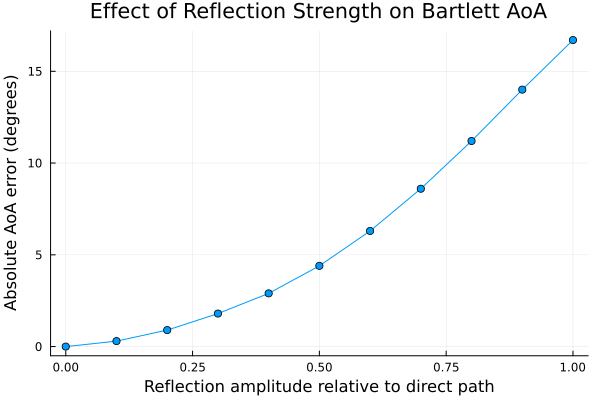

In [12]:
# Plot the bearing error as the reflected path becomes stronger

plot(
    reflection_amplitude_test,
    abs.(reflection_errors),
    marker = :circle,
    xlabel = "Reflection amplitude relative to direct path",
    ylabel = "Absolute AoA error (degrees)",
    title = "Effect of Reflection Strength on Bartlett AoA",
    legend = false
)

## Summary

A simple geometry-based multipath model was applied to the proposed switched UCA architecture. The transmitter and reflector positions were used to determine the direct and reflected propagation distances, the excess path length, the reflected arrival direction and the corresponding phase shift.

Centre referencing successfully removed the changing common signal phase between switch positions, but it could not remove the direction-dependent reflected component. The resulting multipath measurement distorted the Bartlett spatial response and produced a bias in the estimated transmitter direction.

For the example geometry used here, a reflected signal with half the amplitude of the direct path shifted the estimate from $30^\circ$ to approximately $34.4^\circ$. Increasing the reflected signal strength produced progressively larger errors, showing that Bartlett becomes less reliable as coherent reflected energy approaches the strength of the direct path.

These results establish multipath as an important limitation of the baseline Bartlett estimator and provide a controlled scenario for later comparison with alternative direction-finding algorithms.